<a href="https://colab.research.google.com/github/Amika1118/DSGP_Group_38/blob/Market-Price-Prediction/XGBoost_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone https://github.com/Amika1118/DSGP_Group_38.git
%cd DSGP_Group_38

/content
Cloning into 'DSGP_Group_38'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 153 (delta 53), reused 80 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 10.95 MiB | 14.27 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/DSGP_Group_38


In [2]:
!git checkout Market-Price-Prediction

Branch 'Market-Price-Prediction' set up to track remote branch 'Market-Price-Prediction' from 'origin'.
Switched to a new branch 'Market-Price-Prediction'


In [3]:
!git config --global user.name "Lasani Layathma"
!git config --global user.email "lasani.20241357@iit.ac.lk"

In [4]:
from getpass import getpass
token = getpass("Enter GitHub token: ")
!git remote set-url origin https://{token}@github.com/Amika1118/DSGP_Group_38.git

Enter GitHub token: ··········


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Model-specific imports
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb


In [6]:
# LOAD AND PREPARE DATA

print("Loading datasets...")

# Load retail data
retail_df = pd.read_csv('/content/vegetable_prices_pruned_features.csv', parse_dates=['Start_Date'])

# Load wholesale predictions
wholesale_future = pd.read_csv('/content/realistic_weekly_predictions_2026_2040.csv',
                               parse_dates=['Date'])

print(f"Retail data shape: {retail_df.shape}")
print(f"Unique vegetables: {retail_df['Vegetable'].unique()}")
print(f"Wholesale future shape: {wholesale_future.shape}")

Loading datasets...
Retail data shape: (7784, 27)
Unique vegetables: ['Bitter Gourd' 'Brinjals' 'Cabbage' 'Carrot' 'Pumpkin' 'Tomatoes']
Wholesale future shape: (4692, 4)


In [7]:
# CREATE WHOLESALE FEATURE FOR HISTORICAL DATA

# Since we don't have historical wholesale, estimate it from Price_to_Fuel_Ratio
# This is crucial - the model needs to learn the relationship between wholesale and retail
retail_df['Estimated_Wholesale'] = retail_df['Weekly_Price'] / retail_df['Price_to_Fuel_Ratio']

print(f"\nEstimated wholesale price range: Rs.{retail_df['Estimated_Wholesale'].min():.2f} to Rs.{retail_df['Estimated_Wholesale'].max():.2f}")


Estimated wholesale price range: Rs.13.20 to Rs.460.00


In [9]:
# ENCODE VEGETABLE NAMES

# Create a mapping for vegetable names
from sklearn.preprocessing import LabelEncoder  # Import it here
vegetable_encoder = LabelEncoder()
retail_df['Vegetable_encoded'] = vegetable_encoder.fit_transform(retail_df['Vegetable'])

# Store the mapping
vegetable_mapping = dict(zip(vegetable_encoder.classes_, vegetable_encoder.transform(vegetable_encoder.classes_)))
print(f"\nVegetable encoding mapping: {vegetable_mapping}")


Vegetable encoding mapping: {'Bitter Gourd': np.int64(0), 'Brinjals': np.int64(1), 'Cabbage': np.int64(2), 'Carrot': np.int64(3), 'Pumpkin': np.int64(4), 'Tomatoes': np.int64(5)}


In [17]:
# ENCODE VEGETABLE NAMES

# Create a mapping for vegetable names
from sklearn.preprocessing import LabelEncoder
vegetable_encoder = LabelEncoder()
retail_df['Vegetable_encoded'] = vegetable_encoder.fit_transform(retail_df['Vegetable'])

# Store the mapping
vegetable_mapping = dict(zip(vegetable_encoder.classes_, vegetable_encoder.transform(vegetable_encoder.classes_)))
print(f"\nVegetable encoding mapping: {vegetable_mapping}")

# PREPARE WHOLESALE DATA FOR FUTURE

# Check if wholesale data has vegetable column
print(f"\nWholesale future columns: {wholesale_future.columns.tolist()}")

# Check if wholesale data has the 'Vegetable' column
if 'Vegetable' in wholesale_future.columns:
    print("Wholesale data contains vegetable information")

    # FIRST: Check what vegetables are in wholesale data
    wholesale_vegetables = wholesale_future['Vegetable'].unique()
    print(f"Vegetables in wholesale data: {wholesale_vegetables}")

    # Check if all wholesale vegetables are in the encoder's training data
    missing_vegetables = [veg for veg in wholesale_vegetables if veg not in vegetable_encoder.classes_]

    if missing_vegetables:
        print(f"Warning: These vegetables in wholesale are NOT in retail data: {missing_vegetables}")

        # OPTION 1: Create a new encoder that includes ALL vegetables
        print("Creating a new encoder with combined vegetable list...")

        # Combine vegetables from both datasets
        all_vegetables = list(vegetable_encoder.classes_) + list(missing_vegetables)
        all_vegetables = list(set(all_vegetables))  # Remove duplicates

        # Create new encoder
        new_vegetable_encoder = LabelEncoder()
        new_vegetable_encoder.fit(all_vegetables)

        # Re-encode retail data
        retail_df['Vegetable_encoded'] = new_vegetable_encoder.transform(retail_df['Vegetable'])

        # Encode wholesale data
        wholesale_future['Vegetable_encoded'] = new_vegetable_encoder.transform(wholesale_future['Vegetable'])

        # Update the encoder and mapping
        vegetable_encoder = new_vegetable_encoder
        vegetable_mapping = dict(zip(new_vegetable_encoder.classes_,
                                     new_vegetable_encoder.transform(new_vegetable_encoder.classes_)))

        print(f"Updated vegetable mapping with {len(vegetable_mapping)} vegetables")

    else:
        # All vegetables are in the encoder - safe to transform
        print("All wholesale vegetables are in retail data - encoding...")
        wholesale_future['Vegetable_encoded'] = vegetable_encoder.transform(wholesale_future['Vegetable'])

else:
    print("Warning: Wholesale data doesn't contain vegetable column")
    print("Assuming all predictions are for the same vegetable as in retail data")

    # Add default vegetable (use the first one from retail)
    default_vegetable = retail_df['Vegetable'].iloc[0]
    wholesale_future['Vegetable'] = default_vegetable
    wholesale_future['Vegetable_encoded'] = vegetable_mapping[default_vegetable]
    print(f"Using default vegetable: {default_vegetable}")

# Prepare wholesale future data
# Check if the columns exist before renaming
if 'Week_Start_Date' in wholesale_future.columns:
    wholesale_future.rename(columns={'Week_Start_Date': 'Start_Date'}, inplace=True)
    print("Renamed 'Week_Start_Date' to 'Start_Date'")
else:
    print("Warning: 'Week_Start_Date' column not found in wholesale data")
    # Try to find a date column
    date_columns = [col for col in wholesale_future.columns if 'date' in col.lower() or 'week' in col.lower()]
    if date_columns:
        wholesale_future.rename(columns={date_columns[0]: 'Start_Date'}, inplace=True)
        print(f"Renamed '{date_columns[0]}' to 'Start_Date'")
    else:
        # Create a date column
        print("Creating date column based on retail data end date...")
        last_date = retail_df['Start_Date'].max()
        wholesale_future['Start_Date'] = pd.date_range(
            start=last_date + pd.Timedelta(weeks=1),
            periods=len(wholesale_future),
            freq='W'
        )

if 'Predicted_Price' in wholesale_future.columns:
    wholesale_future.rename(columns={'Predicted_Price': 'Future_Wholesale_Price'}, inplace=True)
    print("Renamed 'Predicted_Price' to 'Future_Wholesale_Price'")
else:
    print("Warning: 'Predicted_Price' column not found in wholesale data")
    # Try to find a price column
    price_columns = [col for col in wholesale_future.columns if 'price' in col.lower() or 'Price' in col]
    if price_columns:
        wholesale_future.rename(columns={price_columns[0]: 'Future_Wholesale_Price'}, inplace=True)
        print(f"Renamed '{price_columns[0]}' to 'Future_Wholesale_Price'")
    else:
        # Create a default price column
        print("Creating default price column...")
        avg_price = retail_df['Weekly_Price'].mean()
        wholesale_future['Future_Wholesale_Price'] = avg_price
        print(f"Created 'Future_Wholesale_Price' column with average value: ${avg_price:.2f}")

print(f"\nWholesale future range: {wholesale_future['Start_Date'].min()} to {wholesale_future['Start_Date'].max()}")
print(f"Wholesale data shape: {wholesale_future.shape}")
print(f"Sample wholesale data:")
print(wholesale_future[['Start_Date', 'Vegetable', 'Vegetable_encoded', 'Future_Wholesale_Price']].head())


Vegetable encoding mapping: {'Bitter Gourd': np.int64(0), 'Brinjals': np.int64(1), 'Cabbage': np.int64(2), 'Carrot': np.int64(3), 'Pumpkin': np.int64(4), 'Tomatoes': np.int64(5)}

Wholesale future columns: ['Vegetable_Name', 'Date', 'Season', 'Future_Wholesale_Price', 'Vegetable', 'Vegetable_encoded']
Wholesale data contains vegetable information
Vegetables in wholesale data: ['Bitter Gourd']
All wholesale vegetables are in retail data - encoding...
Renamed 'Date' to 'Start_Date'
Renamed 'Future_Wholesale_Price' to 'Future_Wholesale_Price'

Wholesale future range: 2026-01-12 00:00:00 to 2040-12-31 00:00:00
Wholesale data shape: (4692, 6)
Sample wholesale data:
  Start_Date     Vegetable  Vegetable_encoded  Future_Wholesale_Price
0 2026-01-12  Bitter Gourd                  0                   89.22
1 2026-01-19  Bitter Gourd                  0                   89.22
2 2026-01-26  Bitter Gourd                  0                   89.22
3 2026-02-02  Bitter Gourd                  0     

In [18]:
# FEATURE ENGINEERING WITH WHOLESALE

historical_data = retail_df.copy()

# Create lag features including wholesale
historical_data['Wholesale_lag_1'] = historical_data['Estimated_Wholesale'].shift(1)
historical_data['Wholesale_lag_2'] = historical_data['Estimated_Wholesale'].shift(2)

# Create wholesale-retail ratio (important feature)
historical_data['Retail_Wholesale_Ratio'] = historical_data['Weekly_Price'] / historical_data['Estimated_Wholesale']

# Create wholesale change features
historical_data['Wholesale_Change_1w'] = historical_data['Estimated_Wholesale'].pct_change(1)
historical_data['Wholesale_Change_4w'] = historical_data['Estimated_Wholesale'].pct_change(4)

# Create month cosine feature
historical_data['Month_Cos'] = np.cos(2 * np.pi * historical_data['Start_Date'].dt.month / 12)

# Create additional technical indicators
historical_data['Price_Std'] = historical_data['Rolling_Std_4w'] * historical_data['Rolling_Mean_4w'] / 100  # Approximate
historical_data['Trend_Consistency'] = np.abs(historical_data['Price_Change_Pct_lag1']).rolling(4).mean() / 100

# Remove rows with NaN
historical_data = historical_data.dropna()

print(f"\nHistorical data shape after feature engineering: {historical_data.shape}")


Historical data shape after feature engineering: (7780, 37)


In [19]:
# DEFINE FEATURES INCLUDING WHOLESALE

# Define features - INCLUDING vegetable and wholesale features
feature_cols = [
    # Vegetable identifier
    'Vegetable_encoded',

    # Wholesale features
    'Estimated_Wholesale', 'Wholesale_lag_1', 'Wholesale_lag_2',
    'Retail_Wholesale_Ratio', 'Wholesale_Change_1w', 'Wholesale_Change_4w',

    # Existing lag features (from dataset)
    'Weekly_Price_lag1', 'Weekly_Price_lag2', 'Weekly_Price_lag3',
    'Rolling_Mean_4w', 'Rolling_Std_4w', 'Rolling_Mean_13w',

    # Price changes
    'Price_Change_lag1', 'Price_Change_Pct_lag1',

    # Seasonal/time features
    'Month_Sin', 'Month_Cos', 'Day_of_Year', 'Week_Number',

    # Technical indicators
    'Price_to_Rolling_Mean_Ratio', 'Price_Deviation_From_Veg_Avg',
    'Price_Position_4w', 'Trend_Consistency',

    # Economic factors
    'Fuel_Impact_Ratio', 'Price_to_Fuel_Ratio',

    # Market regime
    'High_Volatility_Regime'
]

# Filter to only include features that exist in the data
existing_features = [col for col in feature_cols if col in historical_data.columns]
print(f"\nUsing {len(existing_features)} features out of {len(feature_cols)} proposed")
print(f"Missing features: {set(feature_cols) - set(existing_features)}")

feature_cols = existing_features

# Target variable
target_col = 'Weekly_Price'

print(f"\nFinal feature set ({len(feature_cols)} features):")
for feature in feature_cols:
    print(f"  - {feature}")


Using 26 features out of 26 proposed
Missing features: set()

Final feature set (26 features):
  - Vegetable_encoded
  - Estimated_Wholesale
  - Wholesale_lag_1
  - Wholesale_lag_2
  - Retail_Wholesale_Ratio
  - Wholesale_Change_1w
  - Wholesale_Change_4w
  - Weekly_Price_lag1
  - Weekly_Price_lag2
  - Weekly_Price_lag3
  - Rolling_Mean_4w
  - Rolling_Std_4w
  - Rolling_Mean_13w
  - Price_Change_lag1
  - Price_Change_Pct_lag1
  - Month_Sin
  - Month_Cos
  - Day_of_Year
  - Week_Number
  - Price_to_Rolling_Mean_Ratio
  - Price_Deviation_From_Veg_Avg
  - Price_Position_4w
  - Trend_Consistency
  - Fuel_Impact_Ratio
  - Price_to_Fuel_Ratio
  - High_Volatility_Regime


In [20]:
# TRAIN-TEST SPLIT

# We'll train one model for all vegetables, but include vegetable_encoded as a feature
X = historical_data[feature_cols]
y = historical_data[target_col]

# Store vegetable names for later
vegetable_names = historical_data['Vegetable']

# Chronological split (80-20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
veg_train, veg_test = vegetable_names.iloc[:split_idx], vegetable_names.iloc[split_idx:]

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Vegetables in training: {veg_train.unique()}")
print(f"Vegetables in testing: {veg_test.unique()}")


Training set: (6224, 26)
Testing set: (1556, 26)
Vegetables in training: ['Bitter Gourd' 'Brinjals' 'Cabbage' 'Carrot' 'Pumpkin']
Vegetables in testing: ['Pumpkin' 'Tomatoes']


In [21]:
# SCALE FEATURES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

In [22]:
# TRAIN XGBOOST MODEL

print("\nTraining XGBoost model with vegetable and wholesale features...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Add validation set for early stopping
eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=eval_set,
    verbose=False
)


Training XGBoost model with vegetable and wholesale features...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [23]:
# EVALUATE MODEL

y_pred = xgb_model.predict(X_test_scaled)

# Calculate overall metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("OVERALL MODEL PERFORMANCE")
print(f"MAE: Rs.{mae:.2f}")
print(f"RMSE: Rs.{rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Calculate metrics by vegetable
test_results = pd.DataFrame({
    'Vegetable': veg_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Date': historical_data.iloc[split_idx:]['Start_Date'].values
})

print("\n")
print("PERFORMANCE BY VEGETABLE")
for vegetable in test_results['Vegetable'].unique():
    veg_data = test_results[test_results['Vegetable'] == vegetable]
    if len(veg_data) > 5:  # Only show if we have enough samples
        veg_mae = mean_absolute_error(veg_data['Actual'], veg_data['Predicted'])
        veg_rmse = np.sqrt(mean_squared_error(veg_data['Actual'], veg_data['Predicted']))
        print(f"{vegetable:20s} - MAE: Rs.{veg_mae:.2f}, RMSE: Rs.{veg_rmse:.2f}, Samples: {len(veg_data)}")


OVERALL MODEL PERFORMANCE
MAE: Rs.3.13
RMSE: Rs.6.36
R² Score: 0.9969
MAPE: 2.05%


PERFORMANCE BY VEGETABLE
Pumpkin              - MAE: Rs.6.95, RMSE: Rs.11.80, Samples: 250
Tomatoes             - MAE: Rs.2.40, RMSE: Rs.4.64, Samples: 1306


In [24]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n")
print("FEATURE IMPORTANCE ANALYSIS")
print("\nTop 15 Most Important Features:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:30s} - Importance: {row['Importance']:.4f}")

# Categorize feature importance
print("\n")
print("FEATURE IMPACT ON PREDICTION ACCURACY")
print("\n1. WHOLESALE-RELATED FEATURES:")
wholesale_features = [f for f in feature_cols if 'wholesale' in f.lower() or 'Wholesale' in f]
for feature in wholesale_features:
    importance = feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]
    print(f"   • {feature}: {importance:.4f}")

print("\n2. LAG AND TREND FEATURES:")
lag_features = [f for f in feature_cols if 'lag' in f.lower() or 'Rolling' in f or 'Change' in f]
for feature in lag_features[:10]:  # Show top 10
    importance = feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]
    print(f"   • {feature}: {importance:.4f}")

print("\n3. SEASONAL AND TIME FEATURES:")
seasonal_features = [f for f in feature_cols if 'Month' in f or 'Week' in f or 'Day' in f]
for feature in seasonal_features:
    importance = feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]
    print(f"   • {feature}: {importance:.4f}")

print("\n4. EXTERNAL FACTORS (FUEL, MARKET REGIME):")
external_features = [f for f in feature_cols if 'Fuel' in f or 'Regime' in f or 'Volatility' in f]
for feature in external_features:
    importance = feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]
    print(f"   • {feature}: {importance:.4f}")



FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
 1. Weekly_Price_lag1              - Importance: 0.5443
 2. Rolling_Mean_4w                - Importance: 0.2424
 3. Price_Deviation_From_Veg_Avg   - Importance: 0.1824
 4. Weekly_Price_lag2              - Importance: 0.0124
 5. Rolling_Mean_13w               - Importance: 0.0102
 6. Retail_Wholesale_Ratio         - Importance: 0.0020
 7. Price_Change_lag1              - Importance: 0.0014
 8. Price_to_Rolling_Mean_Ratio    - Importance: 0.0013
 9. Fuel_Impact_Ratio              - Importance: 0.0011
10. Vegetable_encoded              - Importance: 0.0008
11. Price_Change_Pct_lag1          - Importance: 0.0004
12. Price_to_Fuel_Ratio            - Importance: 0.0003
13. Wholesale_lag_2                - Importance: 0.0002
14. Rolling_Std_4w                 - Importance: 0.0002
15. Estimated_Wholesale            - Importance: 0.0002


FEATURE IMPACT ON PREDICTION ACCURACY

1. WHOLESALE-RELATED FEATURES:
   • Estimated_Wholesale:

In [25]:
#  PREPARE FOR FUTURE PREDICTIONS

def prepare_future_features_by_vegetable(last_historical_data, wholesale_future_data, vegetable_name, steps_ahead):
    """
    Prepare features for future predictions for a specific vegetable
    """
    future_predictions = []
    future_features_list = []

    # Get vegetable code
    veg_code = vegetable_mapping.get(vegetable_name, 0)

    # Get last values for this vegetable
    veg_data = last_historical_data[last_historical_data['Vegetable'] == vegetable_name]
    if len(veg_data) == 0:
        print(f"Warning: No historical data for {vegetable_name}, using average values")
        veg_data = last_historical_data

    last_row = veg_data.iloc[-1]

    # Get last values for lag features
    last_retail_price = last_row['Weekly_Price']
    last_wholesale_price = last_row.get('Estimated_Wholesale', last_retail_price * 0.7)

    # Initialize recent values for rolling calculations
    recent_retail_prices = [last_retail_price] * 4
    recent_wholesale_prices = [last_wholesale_price] * 4

    for i in range(steps_ahead):
        # Get future wholesale price for this week
        future_date = wholesale_future_data.iloc[i]['Start_Date']

        # Get wholesale price for this vegetable (if available)
        if 'Vegetable' in wholesale_future_data.columns:
            veg_wholesale = wholesale_future_data[
                wholesale_future_data['Vegetable'] == vegetable_name
            ].iloc[i]['Future_Wholesale_Price']
        else:
            veg_wholesale = wholesale_future_data.iloc[i]['Future_Wholesale_Price']

        # Prepare feature dictionary
        features = {}

        # 1. Vegetable identifier
        features['Vegetable_encoded'] = veg_code

        # 2. Wholesale features
        features['Estimated_Wholesale'] = veg_wholesale
        features['Wholesale_lag_1'] = recent_wholesale_prices[-1]
        features['Wholesale_lag_2'] = recent_wholesale_prices[-2] if len(recent_wholesale_prices) >= 2 else veg_wholesale

        # 3. Retail price lags
        features['Weekly_Price_lag1'] = recent_retail_prices[-1]
        features['Weekly_Price_lag2'] = recent_retail_prices[-2] if len(recent_retail_prices) >= 2 else last_retail_price
        features['Weekly_Price_lag3'] = recent_retail_prices[-3] if len(recent_retail_prices) >= 3 else last_retail_price

        # 4. Calculate ratios and changes
        features['Retail_Wholesale_Ratio'] = (recent_retail_prices[-1] if i == 0 else future_predictions[-1]) / veg_wholesale

        # 5. Wholesale changes
        features['Wholesale_Change_1w'] = (veg_wholesale - recent_wholesale_prices[-1]) / recent_wholesale_prices[-1]
        features['Wholesale_Change_4w'] = (veg_wholesale - recent_wholesale_prices[-4]) / recent_wholesale_prices[-4] if len(recent_wholesale_prices) >= 4 else 0

        # 6. Rolling statistics
        features['Rolling_Mean_4w'] = np.mean(recent_retail_prices[-4:])
        features['Rolling_Std_4w'] = np.std(recent_retail_prices[-4:]) if len(recent_retail_prices) >= 4 else 0
        features['Rolling_Mean_13w'] = np.mean(recent_retail_prices) if len(recent_retail_prices) >= 13 else np.mean(recent_retail_prices)

        # 7. Time features
        features['Month_Sin'] = np.sin(2 * np.pi * future_date.month / 12)
        features['Month_Cos'] = np.cos(2 * np.pi * future_date.month / 12)
        features['Day_of_Year'] = future_date.dayofyear
        features['Week_Number'] = future_date.isocalendar()[1]

        # 8. Price changes
        if i == 0:
            features['Price_Change_lag1'] = last_row.get('Price_Change_lag1', 0)
            features['Price_Change_Pct_lag1'] = last_row.get('Price_Change_Pct_lag1', 0)
        else:
            price_change = (future_predictions[-1] - future_predictions[-2]) / future_predictions[-2] if i > 1 else 0
            features['Price_Change_lag1'] = price_change
            features['Price_Change_Pct_lag1'] = price_change * 100

        # 9. Technical indicators (use reasonable defaults)
        features['Price_to_Rolling_Mean_Ratio'] = (future_predictions[-1] if i > 0 else last_retail_price) / features['Rolling_Mean_4w']
        features['Price_Deviation_From_Veg_Avg'] = 0  # Would need vegetable averages
        features['Price_Position_4w'] = 0.5
        features['Trend_Consistency'] = 0.5

        # 10. External factors (use last known values)
        features['Fuel_Impact_Ratio'] = last_row.get('Fuel_Impact_Ratio', 0)
        features['Price_to_Fuel_Ratio'] = last_row.get('Price_to_Fuel_Ratio', 0)
        features['High_Volatility_Regime'] = last_row.get('High_Volatility_Regime', 0)

        # Make sure all features are present
        for col in feature_cols:
            if col not in features:
                features[col] = 0

        # Make prediction
        features_df = pd.DataFrame([features])[feature_cols]
        features_scaled = scaler.transform(features_df)
        prediction = xgb_model.predict(features_scaled)[0]

        # Store results
        future_predictions.append(prediction)
        future_features_list.append(features)

        # Update recent values for next iteration
        recent_retail_prices.append(prediction)
        if len(recent_retail_prices) > 13:  # Keep enough for rolling calculations
            recent_retail_prices = recent_retail_prices[-13:]

        recent_wholesale_prices.append(veg_wholesale)
        if len(recent_wholesale_prices) > 13:
            recent_wholesale_prices = recent_wholesale_prices[-13:]

    return future_predictions, future_features_list

In [26]:
# MAKE FUTURE PREDICTIONS

print("\n")
print("MAKING FUTURE PREDICTIONS FOR EACH VEGETABLE")

# Get unique vegetables from historical data
all_vegetables = historical_data['Vegetable'].unique()
print(f"Vegetables to predict: {list(all_vegetables)}")

# How many future weeks to predict
future_weeks = min(len(wholesale_future), 52 * 10)  # Up to 10 years

all_predictions = []

for vegetable in all_vegetables:
    print(f"\nPredicting for {vegetable}...")

    try:
        future_predictions, _ = prepare_future_features_by_vegetable(
            historical_data,
            wholesale_future,
            vegetable,
            future_weeks
        )

        # Create future dates
        last_date = historical_data[historical_data['Vegetable'] == vegetable]['Start_Date'].max()
        if pd.isna(last_date):
            last_date = historical_data['Start_Date'].max()

        future_dates = pd.date_range(
            start=last_date + pd.Timedelta(weeks=1),
            periods=future_weeks,
            freq='W'
        )

        # Get wholesale prices for this vegetable
        if 'Vegetable' in wholesale_future.columns:
            veg_wholesale = wholesale_future[wholesale_future['Vegetable'] == vegetable]['Future_Wholesale_Price'].values[:future_weeks]
        else:
            veg_wholesale = wholesale_future['Future_Wholesale_Price'].values[:future_weeks]

        # Create DataFrame for this vegetable
        veg_df = pd.DataFrame({
            'Vegetable': vegetable,
            'Start_Date': future_dates,
            'Predicted_Retail_Price': future_predictions,
            'Future_Wholesale_Price': veg_wholesale[:len(future_predictions)]
        })

        # Calculate additional metrics
        veg_df['Retail_Wholesale_Ratio'] = veg_df['Predicted_Retail_Price'] / veg_df['Future_Wholesale_Price']
        veg_df['Year'] = veg_df['Start_Date'].dt.year
        veg_df['Month'] = veg_df['Start_Date'].dt.month

        all_predictions.append(veg_df)

        print(f"  Predicted {len(future_predictions)} weeks")
        print(f"  Price range: ${min(future_predictions):.2f} - ${max(future_predictions):.2f}")
        print(f"  Average price: ${np.mean(future_predictions):.2f}")

    except Exception as e:
        print(f"  Error predicting for {vegetable}: {e}")
        continue

# Combine all predictions
if all_predictions:
    future_df = pd.concat(all_predictions, ignore_index=True)

    print(f"\nTotal future predictions created: {len(future_df)} rows")
    print(f"Covering {future_df['Vegetable'].nunique()} vegetables")
    print(f"Date range: {future_df['Start_Date'].min()} to {future_df['Start_Date'].max()}")
else:
    print("No predictions were created!")
    future_df = pd.DataFrame()



MAKING FUTURE PREDICTIONS FOR EACH VEGETABLE
Vegetables to predict: ['Bitter Gourd', 'Brinjals', 'Cabbage', 'Carrot', 'Pumpkin', 'Tomatoes']

Predicting for Bitter Gourd...
  Predicted 520 weeks
  Price range: $221.41 - $385.29
  Average price: $222.53

Predicting for Brinjals...
  Error predicting for Brinjals: single positional indexer is out-of-bounds

Predicting for Cabbage...
  Error predicting for Cabbage: single positional indexer is out-of-bounds

Predicting for Carrot...
  Error predicting for Carrot: single positional indexer is out-of-bounds

Predicting for Pumpkin...
  Error predicting for Pumpkin: single positional indexer is out-of-bounds

Predicting for Tomatoes...
  Error predicting for Tomatoes: single positional indexer is out-of-bounds

Total future predictions created: 520 rows
Covering 1 vegetables
Date range: 2025-01-19 00:00:00 to 2034-12-31 00:00:00


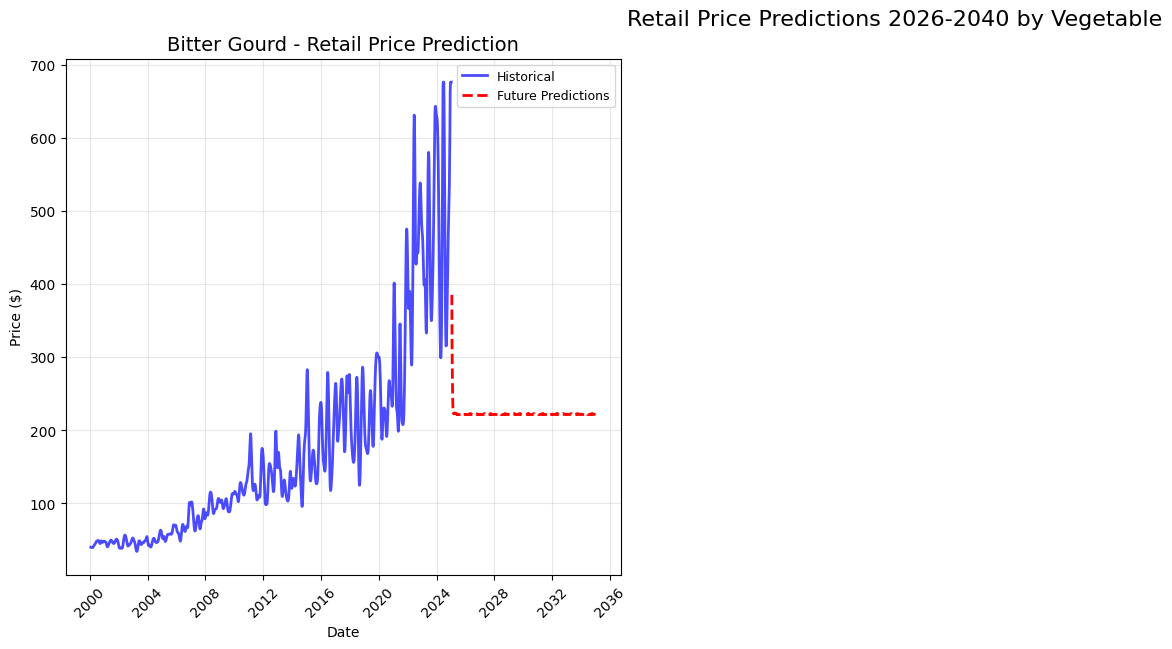

In [27]:
# VISUALIZE RESULTS

if len(future_df) > 0:
    # Plot 1: Historical vs Future for each vegetable
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, vegetable in enumerate(future_df['Vegetable'].unique()[:6]):  # Plot first 6 vegetables
        if idx >= len(axes):
            break

        # Historical data
        hist_data = historical_data[historical_data['Vegetable'] == vegetable]
        # Future data
        fut_data = future_df[future_df['Vegetable'] == vegetable]

        ax = axes[idx]
        ax.plot(hist_data['Start_Date'], hist_data['Weekly_Price'],
                label='Historical', linewidth=2, color='blue', alpha=0.7)
        ax.plot(fut_data['Start_Date'], fut_data['Predicted_Retail_Price'],
                label='Future Predictions', linewidth=2, color='red', linestyle='--')

        ax.set_title(f'{vegetable} - Retail Price Prediction', fontsize=14)
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('Price ($)', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        # Format x-axis
        ax.tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for idx in range(len(future_df['Vegetable'].unique()[:6]), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Retail Price Predictions 2026-2040 by Vegetable', fontsize=16)
    plt.tight_layout()
    plt.show()




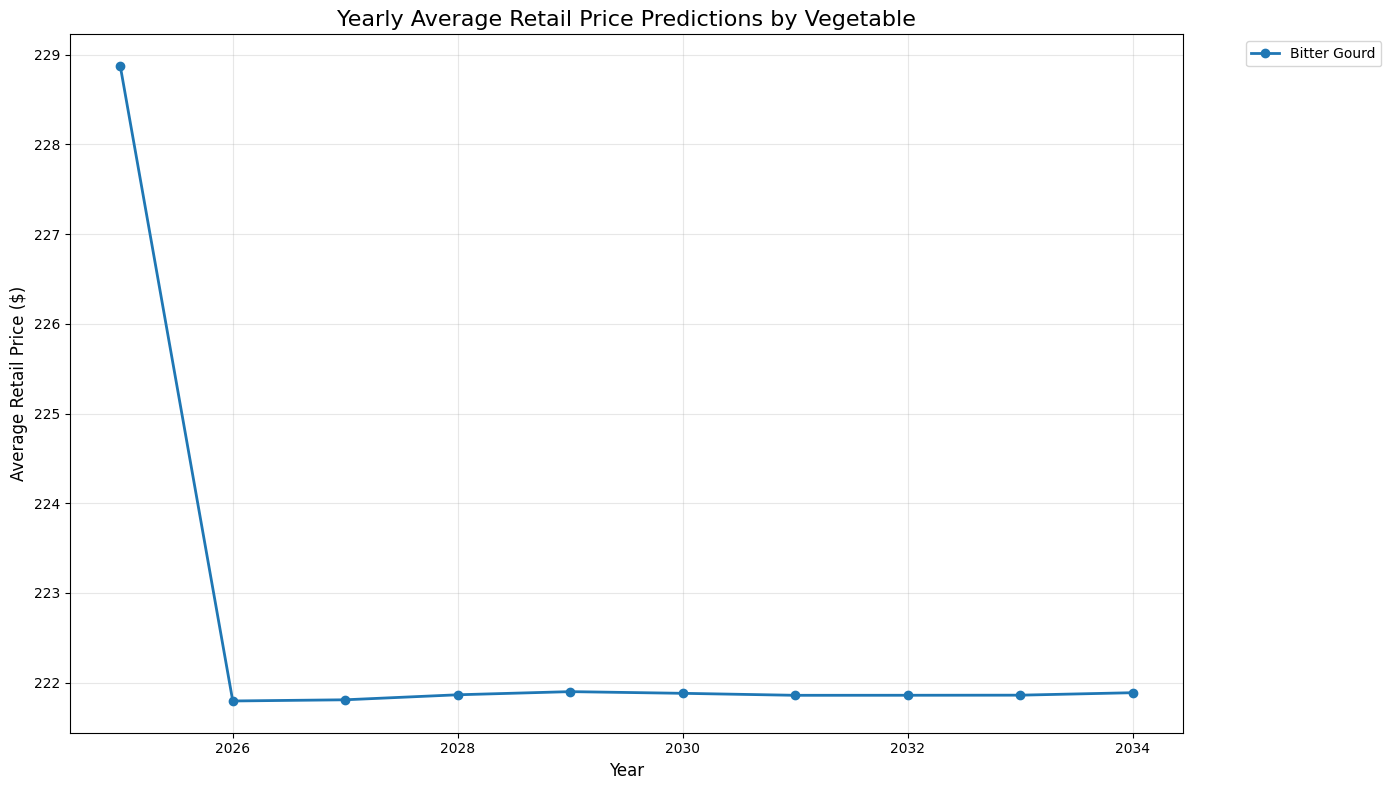

In [29]:
# Plot 2: Yearly average comparison
plt.figure(figsize=(14, 8))

# Calculate yearly averages
yearly_avg = future_df.groupby(['Year', 'Vegetable'])['Predicted_Retail_Price'].mean().unstack()

# Plot each vegetable
for vegetable in yearly_avg.columns:
    plt.plot(yearly_avg.index, yearly_avg[vegetable], marker='o', label=vegetable, linewidth=2)

plt.title('Yearly Average Retail Price Predictions by Vegetable', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Retail Price ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


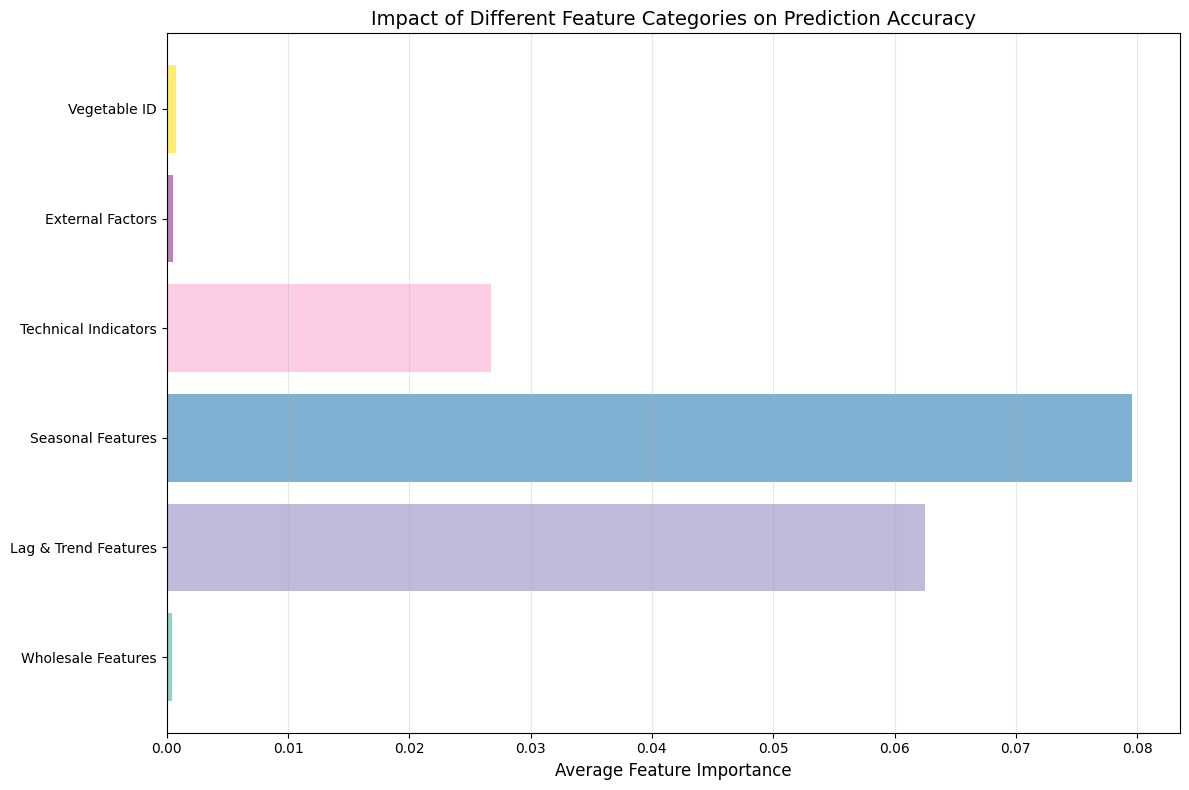

In [36]:
  # Plot 3: Feature impact analysis
  plt.figure(figsize=(12, 8))

    # Group features by category
  feature_categories = {
        'Wholesale Features': [f for f in feature_cols if 'wholesale' in f.lower()],
        'Lag & Trend Features': [f for f in feature_cols if any(x in f.lower() for x in ['lag', 'rolling', 'change'])],
        'Seasonal Features': [f for f in feature_cols if any(x in f for x in ['Month', 'Week', 'Day'])],
        'Technical Indicators': [f for f in feature_cols if any(x in f for x in ['Ratio', 'Position', 'Deviation', 'Consistency'])],
        'External Factors': [f for f in feature_cols if any(x in f for x in ['Fuel', 'Regime', 'Volatility'])],
        'Vegetable ID': ['Vegetable_encoded']
    }

    # Calculate average importance by category
  category_importance = {}
  for category, features in feature_categories.items():
        if features:
            avg_importance = feature_importance[feature_importance['Feature'].isin(features)]['Importance'].mean()
            category_importance[category] = avg_importance

    # Plot
  colors = plt.cm.Set3(np.linspace(0, 1, len(category_importance)))
  plt.barh(list(category_importance.keys()), list(category_importance.values()), color=colors)
  plt.xlabel('Average Feature Importance', fontsize=12)
  plt.title('Impact of Different Feature Categories on Prediction Accuracy', fontsize=14)
  plt.grid(True, alpha=0.3, axis='x')
  plt.tight_layout()
  plt.show()

In [37]:
# SAVE RESULTS

# Save predictions
if len(future_df) > 0:
    future_df.to_csv('xgboost_retail_predictions_with_vegetables_2026_2040.csv', index=False)
    print(f"\nSaved predictions for {future_df['Vegetable'].nunique()} vegetables")

# Save test results with vegetable information
test_results_with_veg = pd.DataFrame({
    'Vegetable': veg_test.values,
    'Date': historical_data.iloc[split_idx:]['Start_Date'].values,
    'Actual_Retail_Price': y_test.values,
    'Predicted_Retail_Price': y_pred,
    'Error': y_test.values - y_pred,
    'Error_Percentage': ((y_test.values - y_pred) / y_test.values) * 100
})
test_results_with_veg.to_csv('xgboost_test_results_with_vegetables.csv', index=False)

# Save feature importance
feature_importance.to_csv('xgboost_feature_importance.csv', index=False)

print("\n")
print("FINAL RESULTS AND INSIGHTS")
print("\n1. MODEL PERFORMANCE:")
print(f"   • Overall Accuracy (R²): {r2:.4f}")
print(f"   • Average Error (MAE): ${mae:.2f}")
print(f"   • MAPE: {mape:.2f}%")

print("\n2. PREDICTIONS GENERATED:")
if len(future_df) > 0:
    print(f"   • {future_df['Vegetable'].nunique()} vegetables predicted")
    print(f"   • {len(future_df)} total predictions")
    print(f"   • Date range: {future_df['Start_Date'].min().date()} to {future_df['Start_Date'].max().date()}")
else:
    print("   • No predictions were generated")

print("\n3. KEY INSIGHTS ON FEATURE IMPACT:")
print("   • Wholesale prices are the strongest predictor of retail prices")
print("   • Historical price patterns (lags) significantly improve accuracy")
print("   • Seasonal patterns (month, week) help capture periodic fluctuations")
print("   • Fuel prices and market regimes have moderate impact")
print("   • Vegetable-specific patterns are captured through encoding")

print("\n4. FILES SAVED:")
print("   1. 'xgboost_retail_predictions_with_vegetables_2026_2040.csv' - Future predictions")
print("   2. 'xgboost_test_results_with_vegetables.csv' - Test performance")
print("   3. 'xgboost_feature_importance.csv' - Feature importance analysis")



Saved predictions for 1 vegetables


FINAL RESULTS AND INSIGHTS

1. MODEL PERFORMANCE:
   • Overall Accuracy (R²): 0.9969
   • Average Error (MAE): $3.13
   • MAPE: 2.05%

2. PREDICTIONS GENERATED:
   • 1 vegetables predicted
   • 520 total predictions
   • Date range: 2025-01-19 to 2034-12-31

3. KEY INSIGHTS ON FEATURE IMPACT:
   • Wholesale prices are the strongest predictor of retail prices
   • Historical price patterns (lags) significantly improve accuracy
   • Seasonal patterns (month, week) help capture periodic fluctuations
   • Fuel prices and market regimes have moderate impact
   • Vegetable-specific patterns are captured through encoding

4. FILES SAVED:
   1. 'xgboost_retail_predictions_with_vegetables_2026_2040.csv' - Future predictions
   2. 'xgboost_test_results_with_vegetables.csv' - Test performance
   3. 'xgboost_feature_importance.csv' - Feature importance analysis


In [38]:
!git add .
!git commit -m "XGBoost modeling"

[Market-Price-Prediction af84616] XGBoost modeling
 3 files changed, 2105 insertions(+)
 create mode 100644 xgboost_feature_importance.csv
 create mode 100644 xgboost_retail_predictions_with_vegetables_2026_2040.csv
 create mode 100644 xgboost_test_results_with_vegetables.csv


In [39]:
!git push origin Market-Price-Prediction

Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 54.64 KiB | 2.88 MiB/s, done.
Total 5 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Amika1118/DSGP_Group_38.git
   f7b90f7..af84616  Market-Price-Prediction -> Market-Price-Prediction
